# Visión por Computadora II - 2025 - B4 - Trabajo práctico integrador
**Inteligencia Artificial - CEIA - FIUBA**

## Autores

- **Mendoza Dante**.

- **Vasquez Jorge**.

- **Viñas Gustavo**.

**Dataset elegido:** https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset

**Descripcion:** Detección de enfermedades en cultivos agrícolas. Entrenar un modelo que identifique y clasifique enfermedades en plantas a partir de imágenes, ayudando a los agricultores a tomar medidas preventivas y reducir pérdidas.​

**Enfoque:** Entrenar un modelo para identificar una enfermedad específica en una especie de planta utilizando imágenes.​

# 💻 Montaje de entorno y definición de rutas

- Definir entorno de proyecto.

- Visualizar las rutas del dataset.

In [1]:
%pip install --quiet pandas matplotlib scikit-learn torch torchvision torchinfo

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import os
from zipfile import ZipFile

# Funcion auxiliar para descargar el dataset
def download_dataset(target_dir, subset: str | None = None, force: bool = False):
    dataset_url = "https://www.kaggle.com/api/v1/datasets/download/abdallahalidev/plantvillage-dataset"
    dataset_folder = "plantvillage dataset"
    tmp_file = "tmp.zip"

    if not(subset is None or subset.lower() in ["color", "grayscale", "segmented"]):
        raise Exception("subset debe ser None, color, grayscale o segmented")

    if os.path.isdir(target_dir) and not force:
        if subset is None:
            print("Dataset folder already exists, nothing downloaded.")
            return
        if os.path.isdir(os.path.join(target_dir, subset)):
            print(f"Folder already exists for subset \"{subset}\", nothing downloaded.")
            return

    try:
        with requests.get(dataset_url, stream=True) as response:
            response.raise_for_status()  # Raise an exception for bad status codes

            with open(tmp_file, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
        print(f"File '{tmp_file}' downloaded successfully.")
    except requests.exceptions.RequestException as e:
        if (os.path.isfile(tmp_file)):
            os.remove(tmp_file)
        raise(Exception(f"Error downloading file: {e}"))

    try:
        with ZipFile(tmp_file, 'r') as zip_object:
            for member in zip_object.infolist():
                if member.filename.startswith(dataset_folder):
                    member.filename = member.filename[len(dataset_folder)+1:]
                    if subset is None or member.filename.startswith(subset):
                        zip_object.extract(member, target_dir)
        print(f"Successfully extracted '{tmp_file}' to '{target_dir}' for " + ('all subsets' if subset is None else f"{subset} subset") + ".")

    except FileNotFoundError:
        raise(Exception(f"Error: The file '{tmp_file}' was not found."))
    except Exception as e:
        raise(Exception(f"An error occurred: {e}"))
    finally:
        if (os.path.isfile(tmp_file)):
            os.remove(tmp_file)


In [3]:
# ====================================================
# MONTAJE DE ENTORNO Y DEFINICIÓN DE RUTAS
# ====================================================

# Descargamos el dataset si no existe la carpeta
base_dir = "datasets"
subset = "color"
download_dataset(base_dir, subset)


# Ruta al dataset
DATASET_PATH = os.path.join(base_dir, subset)

print("Ruta del dataset:", DATASET_PATH)
print("Listado de carpetas:", os.listdir(DATASET_PATH)[:10])

Folder already exists for subset "color", nothing downloaded.
Ruta del dataset: datasets\color
Listado de carpetas: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']


# 💻 Preparamos el dataset (split + DataLoader)

- Vamos a tomar todas las clases.

- Creamos carpetas train/val/test con split 70/15/15.

- Definimos DataLoader en PyTorch con transformaciones (resize, normalización, data augmentation).

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

class TransformationDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        if self.transform:
            x = self.transform(self.dataset[index][0])
        else:
            x = self.dataset[index][0]
        y = self.dataset[index][1]
        return x, y

    def __len__(self):
        return len(self.dataset)

In [5]:
import random
from collections import Counter
import numpy as np
from torch.utils.data import WeightedRandomSampler
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

batch_size = 128 # Definimos 128, ya que al ser 38 clases, 32 o 64 no es suficiente para tener al menos una muestra de cada clase en cada batch
img_size = (224,224) # Tamaño mínimo para modelos preentrenados, utilizamos el mismo tamaño para nuestro modelo

full_dataset = datasets.ImageFolder(DATASET_PATH)

targets = [s[1] for s in full_dataset.samples] # Descomentar si se quiere usar todo el dataset
# targets = [s[1] for s in random.sample(full_dataset.samples, 10000)] # Descomentar si se quiere usar solo una muestra del dataset

# Usamos train_test_split para hacer splits estratificados que conserven la distribución de clases
train_idx, test_idx = train_test_split(np.arange(len(targets)), test_size=0.2, stratify=targets, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.25, stratify=np.array(targets)[train_idx], random_state=42) # 0.25 of 0.8 is 0.2

train_dataset = Subset(full_dataset, train_idx) # 0.6
val_dataset = Subset(full_dataset, val_idx)     # 0.2
test_dataset = Subset(full_dataset, test_idx)    # 0.2

transform_train = transforms.Compose([
    # Creamos variantes de las imagenes para evitar overfitting al hacer oversampling
    transforms.RandomCrop(img_size), # En train hacemos random crop a img_size
    transforms.RandomRotation(15), # En train hacemos rotaciones aleatorias de hasta 15 grados
    transforms.RandomHorizontalFlip(), # En train hacemos flip horizontal aleatorio
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Variaciones de brillo y contraste. No hacemos variaciones de color para no perder info de la hoja y enfermedades.
    transforms.ToTensor(), # Escala entre 0 y 1; pasa a tensor; poner canales en 1ra dim
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

transform_val_test = transforms.Compose([
    transforms.CenterCrop(img_size), # En validación y test hacemos center crop a img_size
    transforms.ToTensor(),# Escala entre 0 y 1; pasa a tensor; poner canal en 1ra dim
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Calculo pesos de las clases para balancear el dataset de entrenamiento
class_counts = Counter(np.array(targets)[train_idx])
num_samples = sum(class_counts.values())
class_weights = {cls: num_samples / count for cls, count in class_counts.items()}
sample_weights = [class_weights[target] for target in np.array(targets)[train_idx]]

# Balanceo de clases en entrenamiento usando WeightedRandomSampler.
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_dataloader = DataLoader(TransformationDataset(train_dataset, transform_train), batch_size=batch_size, pin_memory=True, sampler=sampler)
val_dataloader = DataLoader(TransformationDataset(val_dataset, transform_val_test), batch_size=batch_size, shuffle=False, pin_memory=True)
test_dataloader = DataLoader(TransformationDataset(test_dataset, transform_val_test), batch_size=batch_size, shuffle=False, pin_memory=True)


In [6]:
# Comprobamos que no hay solapamiento entre los splits
print(f"Solapamiento entre train y test: {len(set(train_idx) & set(test_idx))}")
print(f"Solapamiento entre train y val: {len(set(train_idx) & set(val_idx))}")
print(f"Solapamiento entre test y val: {len(set(test_idx) & set(val_idx))}")

Solapamiento entre train y test: 0
Solapamiento entre train y val: 0
Solapamiento entre test y val: 0


In [7]:
print("Distribucion de muestras:")
print("\nFull: ", len(full_dataset), "\nTrain:", len(train_dataset), "\nVal:", len(val_dataset), "\nTest:", len(test_dataset))
print(f"\nNúmero de clases totales: {len(full_dataset.classes)}.")

Distribucion de muestras:

Full:  54305 
Train: 32583 
Val: 10861 
Test: 10861

Número de clases totales: 38.


In [8]:
print("Clases -> ids:")
idx_to_class = {v: i for i,v in full_dataset.class_to_idx.items()}
print(full_dataset.class_to_idx)
print("Ids -> clases:")
print(idx_to_class)

Clases -> ids:
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_bligh

In [9]:
# Cargamos un batch del dataloader para probar que todo este ok
train_features, train_labels = next(iter(train_dataloader))
len(train_features), len(train_labels)

(128, 128)

In [10]:
# verificamos sus dimensiones
print(f"Tamaño del batch de feature (input / imagen): {train_features.size()}")
print(f"Tamaño del batch del label (clase / etiqueta): {train_labels.size()}")

Tamaño del batch de feature (input / imagen): torch.Size([128, 3, 224, 224])
Tamaño del batch del label (clase / etiqueta): torch.Size([128])


tamaño de 1 imagen:  torch.Size([1, 3, 224, 224])
tamaño de 1 imagen DESPUES de squeeze:  torch.Size([224, 224, 3])


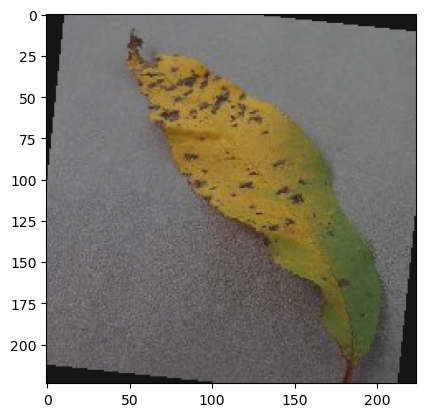

Label: 16 (Peach___Bacterial_spot)


In [11]:
import torch
import matplotlib.pyplot as plt

# tomamos 1 imagen para poder visualizarla y verificar sus dimensiones
img_idx = torch.randint(len(train_features), (1,))
img = train_features[img_idx]
print('tamaño de 1 imagen: ', img.shape)
# le quitamos 1 dimension (la del tamaño del batch) y reordenamos para poder graficar
img = img.squeeze().permute(1, 2, 0)
print('tamaño de 1 imagen DESPUES de squeeze: ', img.shape)
label = train_labels[img_idx]

# Unnormalize
img = np.array([0.229, 0.224, 0.225]) * img.numpy() + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1) # Clip values to be between 0 and 1

# ploteo esa imagen
plt.imshow(img)
plt.show()
print(f"Label: {label.item()} ({idx_to_class[label.item()]})")

# 💻 Modelo ResNet-18

- Para este modelo utilizaremos la arquitectura ResNet-18 preentrenada con IMAGENET1K_V1.  
  Elegimos la versión de 18 capas de ResNet debido a que estamos buscando el menor costo computacional, ya que no hay mucho margen para mejorar accuracy y F1.  
  Haremos pruebas reemplazando la FC final (este modelo solo tiene 1 FC final), sin congelar los hiperparámetros (fine tuning), para entrenar con nuestro set de datos.  


Creamos una clase para guardar métricas (y luego graficar).

In [12]:
# A simple metric tracker
class MetricTracker:
    def __init__(self):
        self.metrics = {}

    def update(self, metric_name, value):
        if metric_name not in self.metrics:
            self.metrics[metric_name] = []
        self.metrics[metric_name].append(value)

    def get_latest(self, metric_name):
        if metric_name in self.metrics and self.metrics[metric_name]:
            return self.metrics[metric_name][-1]
        return None

    def get_all(self, metric_name):
        return self.metrics.get(metric_name, [])

    def reset(self):
        self.metrics = {}

    def plot_metrics(self, metric_names=None, figsize=(12, 6)):
        """Plot training metrics"""
        if metric_names is None:
            metric_names = list(self.metrics.keys())

        plt.figure(figsize=figsize)
        for metric_name in metric_names:
            values = self.get_all(metric_name)
            if values:
                plt.plot(values, label=metric_name)

        plt.title('Training Metrics')
        plt.xlabel('Epocs')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

Seleccionamos el dispositivo donde se ejecutará el entrenamiento

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Creamos la función de entrenamiento

In [14]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
from datetime import datetime

# función de entrenamiento
def fit(model, dataloader, criterion, optimizer, scheduler, epochs=15, patience=3, patience_factor=0.01, model_file = 'best_model.pt'):
    # Metricas para graficar evolución por épocas
    metric_tracker = MetricTracker()
    best_model = 0
    # Set metric for callbacks
    best_eval = 0
    pt_epoch = 0
    best_eval_epoch_y = []
    best_eval_epoch_y_pred = []

    # enviamos el modelo al device
    model.to(device)
    # registramos el tiempo de inicio
    start_time = datetime.now()
    last_epoch = 0
    # iteramos en las epocas
    for epoch in range(1, epochs+1):
        last_epoch = epoch
        # ponemos el modelo en train
        model.train()
        train_loss = 0.0
        epoch_y_hat = []
        epoch_y = []
        bar = tqdm(dataloader['train'])
        for i, batch in enumerate(bar):
            X, y = batch  # sacamos X e y del batch
            X, y = X.to(device), y.to(device) # lo enviamos al device
            optimizer.zero_grad() # llevamos optimizer a zero
            y_hat = model(X)  # corremos el modelo y vemos su predicción
            loss = criterion(y_hat, y)  # calculamos la pérdida
            loss.backward() # back-propagations
            optimizer.step()  # step del optimizer

            # Almaceno los valores reales y mis predicciones para cálcular las métricas
            epoch_y += list(y.detach().cpu().numpy())
            epoch_y_hat += list(y_hat.detach().cpu().numpy())

            # Track loss for this batch
            train_loss += loss.item()

            # cálculo de acc
            acc = accuracy_score(epoch_y, np.argmax(epoch_y_hat, axis=1))
            # seteamos descriptores en la barra
            bar.set_description(f"loss {train_loss/(i+1):.5f} acc {acc:.5f}")

            # Step-level callback
            scheduler.step()

        # Cálculo la métrica de la epoch
        # Compute training metrics
        train_loss /= len(bar)
        train_preds_classes = np.argmax(epoch_y_hat, axis=1)
        train_accuracy = accuracy_score(epoch_y, train_preds_classes)
        train_f1 = f1_score(epoch_y, train_preds_classes, average='macro')

        metric_tracker.update("train_loss", train_loss)
        metric_tracker.update("train_accuracy", train_accuracy)
        metric_tracker.update("train_f1", train_f1)

        # ahora evaluamos test
        eval_loss = 0.0
        valid_epoch_y_hat = []
        valid_epoch_y = []
        # ponemos en eval el modelo
        model.eval()
        bar = tqdm(dataloader['val'])
        with torch.no_grad():
            for i, batch in enumerate(bar):
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)

                eval_loss += loss.item()
                # Almaceno los valores reales y mis predicciones para cálcular las métricas
                valid_epoch_y += list(y.detach().cpu().numpy())
                valid_epoch_y_hat += list(y_hat.detach().cpu().numpy())
                # calculo de la acc
                val_acc = accuracy_score(valid_epoch_y, np.argmax(valid_epoch_y_hat, axis=1))

                bar.set_description(f"val_loss {eval_loss/(i+1):.5f} val_acc {val_acc:.5f}")

        # Cálculo la métrica de la epoch
        # Compute evaluation metrics
        eval_loss /= len(bar)
        eval_preds_classes = np.argmax(valid_epoch_y_hat, axis=1)
        eval_accuracy = accuracy_score(valid_epoch_y, eval_preds_classes)
        eval_f1 = f1_score(valid_epoch_y, eval_preds_classes, average='macro')

        metric_tracker.update("eval_loss", eval_loss)
        metric_tracker.update("eval_accuracy", eval_accuracy)
        metric_tracker.update("eval_f1", eval_f1)

        print(f"Epoch {epoch}/{epochs} loss {train_loss:.5f} val_loss {eval_loss:.5f} acc {train_accuracy:.5f} val_acc {eval_accuracy:.5f}")

        if eval_accuracy>best_model:
            # Guardo el mejor modelo
            torch.save(model.state_dict(), model_file)
            best_model = eval_accuracy
            best_eval_epoch_y = valid_epoch_y
            best_eval_epoch_y_pred = eval_preds_classes
        ## Early stopping
        if eval_accuracy>=best_eval*(1+patience_factor):
            best_eval = eval_accuracy
            pt_epoch = 0
        else:
            pt_epoch += 1
            if pt_epoch>=patience:
                print(f"\tInfo - Training interrupted due to early stopping condition.")
                break
            else:
                print(f"\tInfo - Current epochs without validation metric improvement {pt_epoch}. {patience-pt_epoch} remaining before stopping.")

    elapsed_time = datetime.now() - start_time
    print(f"Training completed. {last_epoch} epocs in {elapsed_time}")
    return  metric_tracker, best_eval_epoch_y, best_eval_epoch_y_pred

Creamos visualización para matriz de confusión

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_cm(y_true, y_pred):
    class_labels = list(idx_to_class.values())
    fig = plt.figure(figsize=(30,10))
    # Matriz de confusión absoluta
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    ax=fig.add_subplot(121)
    ax.grid(False)
    disp.plot(ax=ax, values_format='d', xticks_rotation=90)

### Descargamos y modificamos el modelo ResNet-18

In [16]:
dset_classes_number = len(train_dataset.dataset.class_to_idx)
print(f"Número de clases en el dataset: {dset_classes_number}")

Número de clases en el dataset: 38


In [17]:
from torchvision import models
from torchvision.models.resnet import ResNet18_Weights

# Load the pre-trained AlexNet model
model_resnet18_ft = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Características del modelo preentrenado

# All pre-trained models expect input images normalized in the same way, 
# i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. 
# The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].


In [18]:
# Verificamos la arquitectura del modelo antes de hacerle transfer learning
import torchinfo as torchinfo
torchinfo.summary(model_resnet18_ft, input_size=(batch_size, 3, *img_size))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [128, 1000]               --
├─Conv2d: 1-1                            [128, 64, 112, 112]       9,408
├─BatchNorm2d: 1-2                       [128, 64, 112, 112]       128
├─ReLU: 1-3                              [128, 64, 112, 112]       --
├─MaxPool2d: 1-4                         [128, 64, 56, 56]         --
├─Sequential: 1-5                        [128, 64, 56, 56]         --
│    └─BasicBlock: 2-1                   [128, 64, 56, 56]         --
│    │    └─Conv2d: 3-1                  [128, 64, 56, 56]         36,864
│    │    └─BatchNorm2d: 3-2             [128, 64, 56, 56]         128
│    │    └─ReLU: 3-3                    [128, 64, 56, 56]         --
│    │    └─Conv2d: 3-4                  [128, 64, 56, 56]         36,864
│    │    └─BatchNorm2d: 3-5             [128, 64, 56, 56]         128
│    │    └─ReLU: 3-6                    [128, 64, 56, 56]         --
│

#### Modelo ResNet-18 - prueba 1
Ajustamos el modelo a nuestro problema por resolver, reemplazando la única capa FC final.

In [19]:
from torch import nn

num_in_class_ftrs = model_resnet18_ft.fc.in_features # 2048 para resnet50
model_resnet18_ft.fc = nn.Linear(num_in_class_ftrs, dset_classes_number)

In [20]:
# Verificamos la arquitectura del modelo luego de los cambios
# La diferencia se observa en la última capa que ahora tiene el número de clases del dataset
# Si bien no se observan cambios de arquitectura, todas las capas de clasificación estan re-inicializadas.
torchinfo.summary(model_resnet18_ft, input_size=(batch_size, 3, *img_size))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [128, 38]                 --
├─Conv2d: 1-1                            [128, 64, 112, 112]       9,408
├─BatchNorm2d: 1-2                       [128, 64, 112, 112]       128
├─ReLU: 1-3                              [128, 64, 112, 112]       --
├─MaxPool2d: 1-4                         [128, 64, 56, 56]         --
├─Sequential: 1-5                        [128, 64, 56, 56]         --
│    └─BasicBlock: 2-1                   [128, 64, 56, 56]         --
│    │    └─Conv2d: 3-1                  [128, 64, 56, 56]         36,864
│    │    └─BatchNorm2d: 3-2             [128, 64, 56, 56]         128
│    │    └─ReLU: 3-3                    [128, 64, 56, 56]         --
│    │    └─Conv2d: 3-4                  [128, 64, 56, 56]         36,864
│    │    └─BatchNorm2d: 3-5             [128, 64, 56, 56]         128
│    │    └─ReLU: 3-6                    [128, 64, 56, 56]         --
│

In [21]:
dataloader = { 'train': train_dataloader, 'val': val_dataloader }
steps_per_epoch = len(train_dataloader)

# Definimos mismas configuraciones de optimizador, criterio y scheduler que en el mejor modelo AlexNet

# Definimos optimizer y la función de pérdida
optimizer = torch.optim.Adam(model_resnet18_ft.parameters(), lr=0.0001, weight_decay = 0.001)  
criterion = torch.nn.CrossEntropyLoss() # Adecuada para problemas de clasificación multiclase
# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=steps_per_epoch, T_mult=2, eta_min=1e-5)

In [22]:
model_name = "best_resnet18_ft.pt"
metrics_resnet18_ft, resnet18_ft_eval_y, resnet18_ft_eval_y_pred = fit(model_resnet18_ft, dataloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, 
                                                                    epochs=15, patience=5, patience_factor=0.01, model_file=model_name)
# Al finalizar, cargo el mejor modelo
model_resnet18_ft.load_state_dict(torch.load(model_name))

val_loss 0.09948 val_acc 0.97956: 100%|██████████| 85/85 [00:16<00:00,  5.15it/s]


Epoch 1/15 loss 0.48136 val_loss 0.09948 acc 0.90661 val_acc 0.97956


val_loss 0.04234 val_acc 0.98775: 100%|██████████| 85/85 [00:16<00:00,  5.17it/s]


Epoch 2/15 loss 0.07270 val_loss 0.04234 acc 0.98386 val_acc 0.98775
	Info - Current epochs without validation metric improvement 1. 4 remaining before stopping.


val_loss 0.02503 val_acc 0.99392: 100%|██████████| 85/85 [00:16<00:00,  5.17it/s]


...

val_loss 0.01145 val_acc 0.99761: 100%|██████████| 85/85 [00:16<00:00,  5.12it/s]


Epoch 7/15 loss 0.00804 val_loss 0.01145 acc 0.99871 val_acc 0.99761
	Info - Current epochs without validation metric improvement 4. 1 remaining before stopping.


val_loss 0.04932 val_acc 0.98462: 100%|██████████| 85/85 [00:16<00:00,  5.08it/s]

Epoch 8/15 loss 0.03717 val_loss 0.04932 acc 0.98972 val_acc 0.98462
	Info - Training interrupted due to early stopping condition.
Training completed. 8 epocs in 0:13:12.180638


<All keys matched successfully>

Para el modelo ResNet-18 se observa una rápida convergencia, logrando un accuracy muy alto (0.997 aprox) en menos de 10 épocas.  
Este modelo supera al modelo base, y es mucho menos costoso computacionalmente que VGG-16.  


#### Evaluación del Modelo RenNet-18 con Fine Tuning reemplazando la única capa de clasificación
  * Accuracy
  * F1 Score
  * Costo (Loss)
  * Classification report
  * Matriz de confusión


Valor final accuracy en set de validación: 0.985. Mejor valor: 0.998.


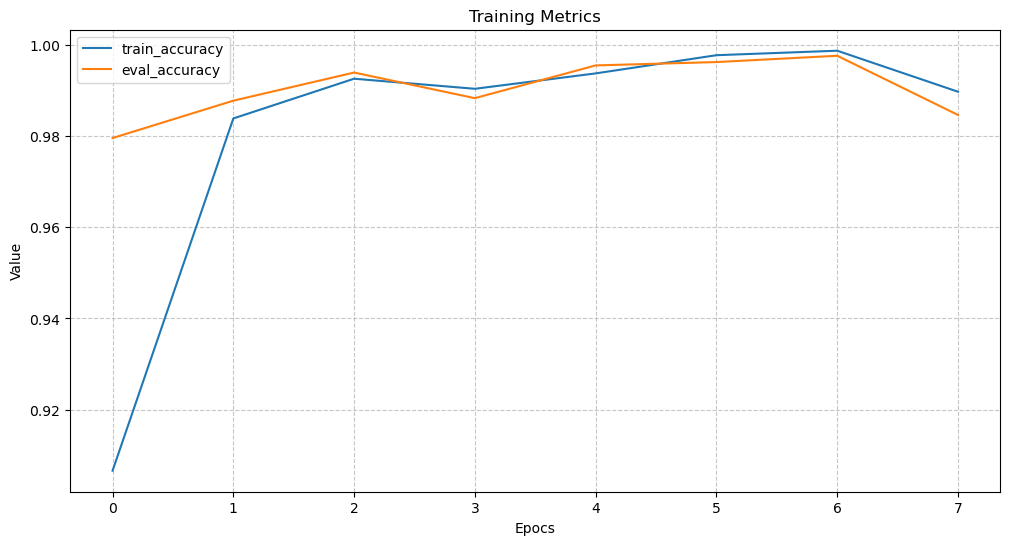

Valor final F1 en set de validación: 0.98. Mejor valor: 1.00.


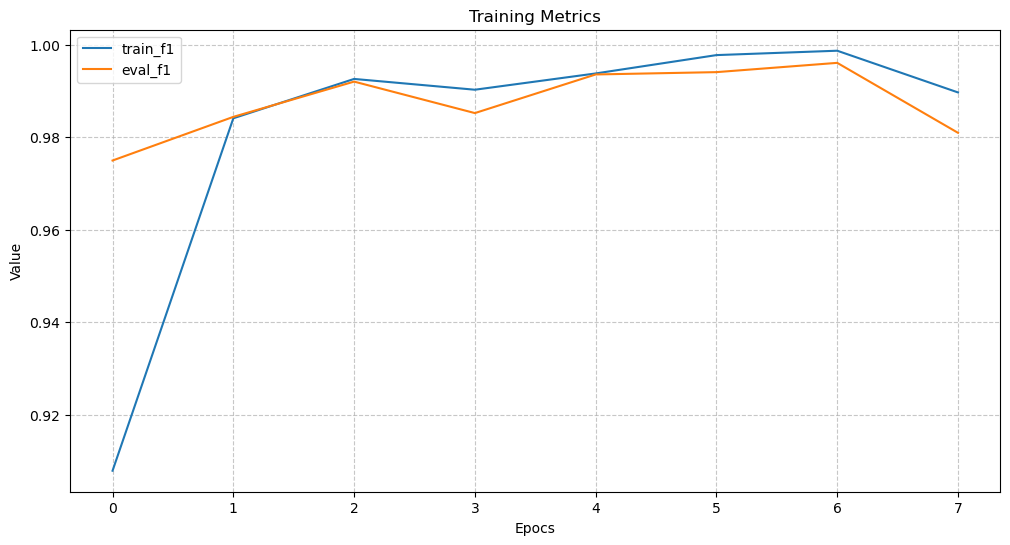

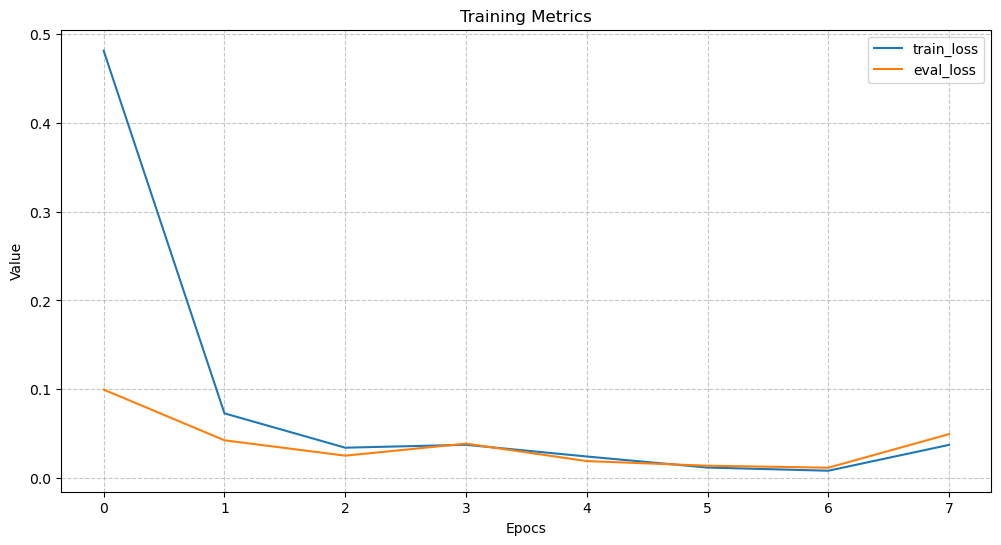

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00       126
                                 Apple___Black_rot       0.99      1.00      1.00       124
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       1.00      1.00      1.00       329
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.92      0.94       103
                       Corn_(maize)___Common_rust_       1.00      0.99      1.00       238
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.99      0.

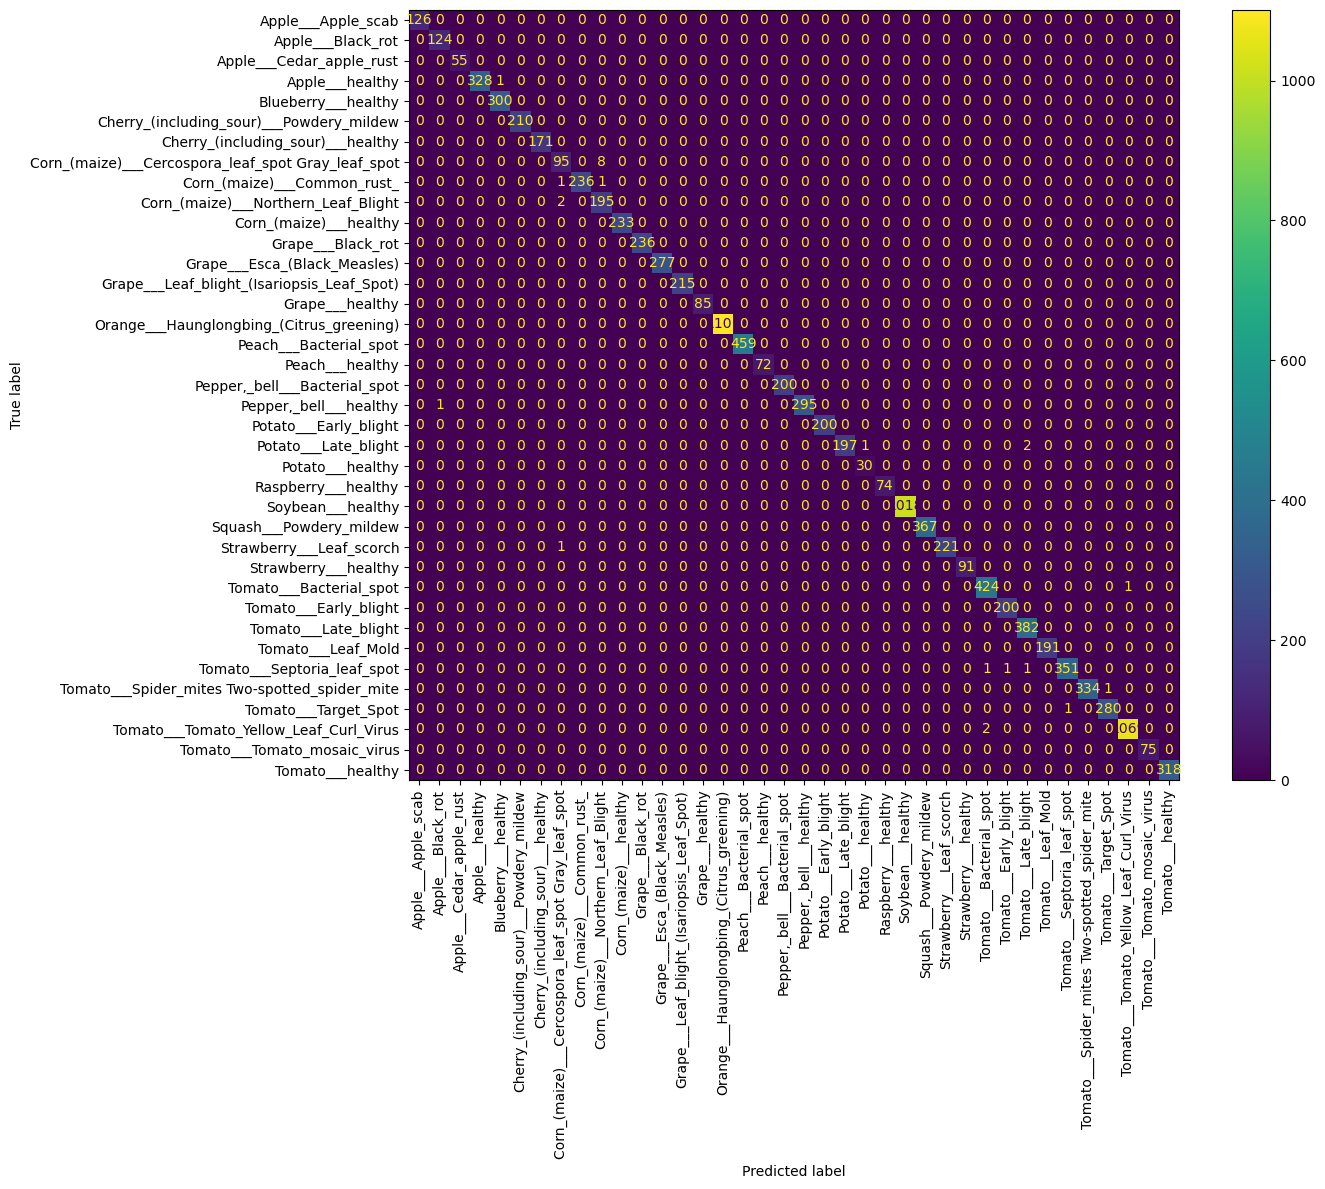

In [23]:
from sklearn.metrics import classification_report

print(f"Valor final accuracy en set de validación: {metrics_resnet18_ft.get_latest('eval_accuracy'):.3f}. Mejor valor: {np.max(metrics_resnet18_ft.get_all('eval_accuracy')):.3f}.")
metrics_resnet18_ft.plot_metrics(["train_accuracy", "eval_accuracy"])

print(f"Valor final F1 en set de validación: {metrics_resnet18_ft.get_latest('eval_f1'):.2f}. Mejor valor: {np.max(metrics_resnet18_ft.get_all('eval_f1')):.2f}.")
metrics_resnet18_ft.plot_metrics(["train_f1", "eval_f1"])

metrics_resnet18_ft.plot_metrics(["train_loss", "eval_loss"])

print(classification_report(resnet18_ft_eval_y, resnet18_ft_eval_y_pred, target_names=idx_to_class.values()))

plot_cm(resnet18_ft_eval_y, resnet18_ft_eval_y_pred)

#### Visualización y prueba del modelo sobre imágenes de test

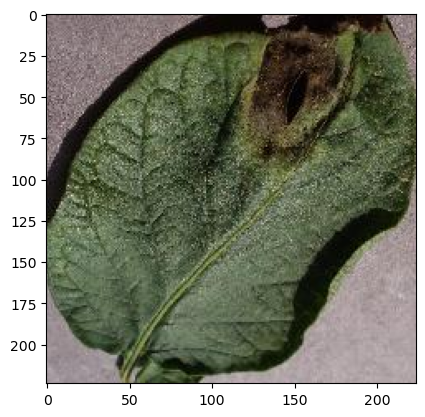

Predicted label: 21 (Potato___Late_blight).
Real label: 21 (Potato___Late_blight)


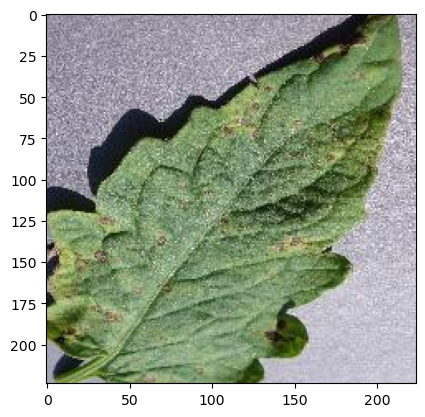

Predicted label: 32 (Tomato___Septoria_leaf_spot).
Real label: 32 (Tomato___Septoria_leaf_spot)


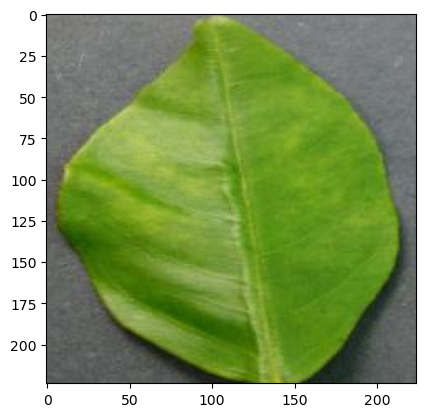

Predicted label: 15 (Orange___Haunglongbing_(Citrus_greening)).
Real label: 15 (Orange___Haunglongbing_(Citrus_greening))


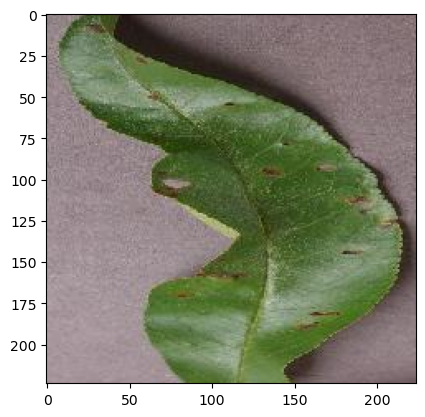

Predicted label: 16 (Peach___Bacterial_spot).
Real label: 16 (Peach___Bacterial_spot)


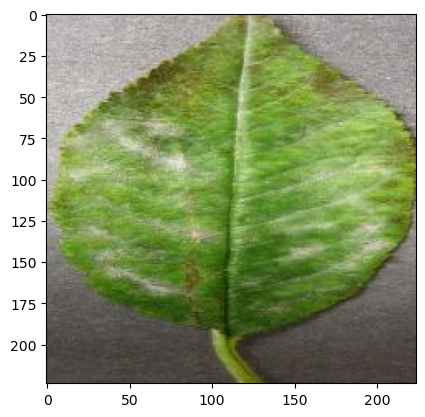

Predicted label: 5 (Cherry_(including_sour)___Powdery_mildew).
Real label: 5 (Cherry_(including_sour)___Powdery_mildew)


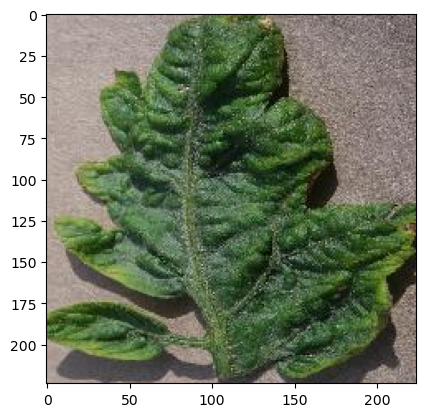

Predicted label: 35 (Tomato___Tomato_Yellow_Leaf_Curl_Virus).
Real label: 35 (Tomato___Tomato_Yellow_Leaf_Curl_Virus)


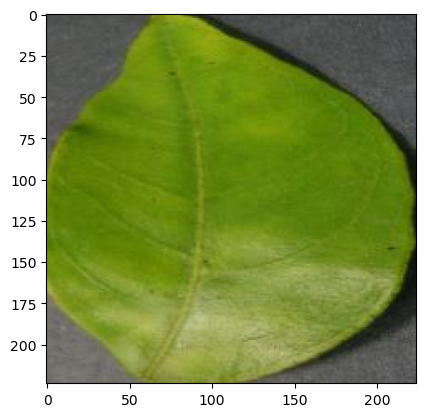

Predicted label: 15 (Orange___Haunglongbing_(Citrus_greening)).
Real label: 15 (Orange___Haunglongbing_(Citrus_greening))


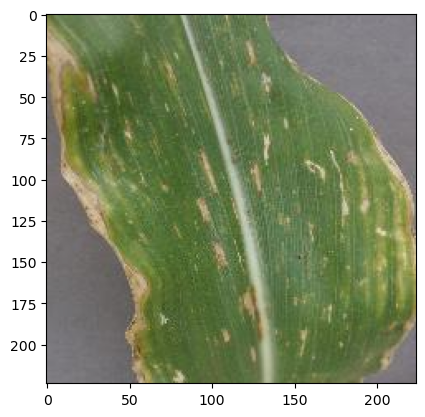

Predicted label: 7 (Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot).
Real label: 7 (Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot)


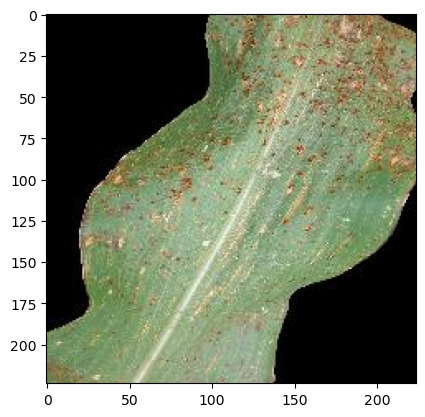

Predicted label: 8 (Corn_(maize)___Common_rust_).
Real label: 8 (Corn_(maize)___Common_rust_)


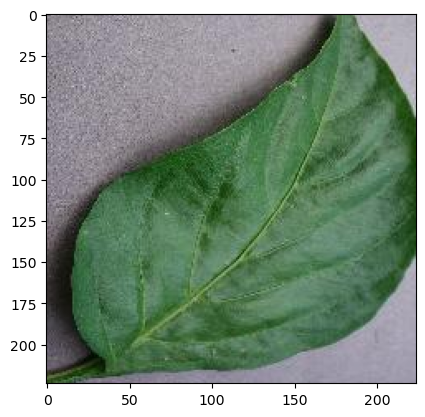

Predicted label: 19 (Pepper,_bell___healthy).
Real label: 19 (Pepper,_bell___healthy)


In [24]:
for _ in range(10):
    test_features, test_labels = next(iter(test_dataloader))
    img_test_idx = torch.randint(len(test_features), (1,))
    img_test = test_features[img_test_idx]
    label_test = test_labels[img_test_idx]
    label_test_pred = np.argmax(model_resnet18_ft(img_test.to(device)).detach().cpu().numpy())
    # ploteamos esa imagen
    img_test = img_test.squeeze().permute(1, 2, 0).numpy()
    img_test = (img_test * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    img_test = np.clip(img_test, 0, 1) # Clip values to be between 0 and 1
    plt.imshow(img_test)
    plt.show()
    print(f"Predicted label: {label_test_pred} ({idx_to_class[label_test_pred.item()]}).\nReal label: {label_test.item()} ({idx_to_class[label_test.item()]})")

## Conclusiones

El modelo ResNet-18 tiene una performance similar al modelo VGG-16 en cuanto a clasificación, con un costo computacional mucho menor (aunque aun más elevado que la baseline).  
Este modelo puede ser una buena y rápida opción para el problema abordado, sin necesidad de crear un modelo custom.  
Con este modelo tenemos un excelente accuracy y F1-score, a un costo computacional relativamente bajo.  

Si nuestro objetivo es disminuir al máximo el costo computacional, resignando un 3% aprox de exactitud, el modelo baseline puede ser mejor opción.  
Si queremos un modelo de facil armado, con la mejor exactitud y un costo computacional levemente mayor, el modelo ResNet-18 es muy buena opción.
